# Main ML Pipeline TEST
Here is a notebook where the machine learning pipeline is being developed.
Many changes will occur, and code may be moved to other notebooks or to .py-files as functionalities are developed.

In [ ]:
# Importing libraries
from pathlib import Path
import numpy as np
import pandas as pd
import sys

In [ ]:
# To be able to access src
sys.path.append(str(Path().resolve().parent))

In [ ]:
# Reloading files if changes have been made
import importlib
import src.preprocessing
import src.models
import src.utils
import src.train
import src.evaluate
import src.visualisation
import src.trainDL
import src.evaluateDL
importlib.reload(src.preprocessing)
importlib.reload(src.models)
importlib.reload(src.utils)
importlib.reload(src.evaluate)
importlib.reload(src.train)
importlib.reload(src.visualisation)
importlib.reload(src.evaluateDL)
importlib.reload(src.trainDL)


In [ ]:
# Set seed for reproducibility
from src.utils import set_seed
set_seed(42)

## Data Cleaning and Preprocessing
(See exploration.ipynb for data exploration.)

In [ ]:
# Load data
from src.preprocessing import load_csvs

folder_1 = Path("..") / "pur-1-data-main" / "data" / "Task 1" / "Public Dataset" / "Gang_Lowers"
folder_2 = Path("..") / "pur-1-data-main" / "data" / "Task 1" / "Public Dataset" / "SCRAMS"

dfs = load_csvs(folder_1, folder_2)
# shape 43x800x13

In [ ]:
# Clean data 
from src.preprocessing import clean_data
dfs = clean_data(dfs)

## Feature Engineering and Selection

In [ ]:
# Define feature columns
# Remove DAS health index and FC voltage supply as they are constants and have no correlation with the target
feature_cols = ['Channel 4 flux', 'Downstream conductivity', 'Downstream water temperature', 'SS1 state', 'SS1 position', 'SS2 state', 'SS2 position', 'Upstream water temperature']

## Model Selection, Training and Evaluation

In [ ]:
results = []

In [ ]:
# Notebook pipeline to avoid repeating code
def classic_pipeline(model_class, param_grid, preprocessing, dfs, feature_cols, results):

    # Preprocess data
    if preprocessing=="flatten":
        from src.utils import flatten_features
        X, y = flatten_features(dfs, feature_cols)
        preprocessing_name = "Flattened_features"
        print("Pipeline with flattened features:")
    elif preprocessing=="extract":
        from src.utils import extract_features
        X, y = extract_features(dfs, feature_cols)
        preprocessing_name = "Extracted_features"
        print("Pipeline with extracted features:")
    else:
        print("Invalid preprocessing method. Choose 'flatten' or 'extract'.")

    # Event IDs
    event_ids = [df["ID"].iloc[0] for df in dfs]

    # Nested cross validation
    from src.train import nested_cross_validation
    auc_scores, acc_scores, f1_scores, all_event_ids, y_true, y_pred, best_model_list, best_params_list = nested_cross_validation(X, y, event_ids, model_class, param_grid)
    
    # Determine hyperparameters for final cross-validation
    from src.utils import get_final_param_grid
    param_grid_final = get_final_param_grid(best_params_list)

    # Run final cross-validation
    from src.train import final_cross_validation
    final_model, final_params = final_cross_validation(X, y, model_class, param_grid_final)

    # Save model for later inference
    from src.utils import save_model
    save_model(final_model, f"{model_class.__name__}_{preprocessing_name}")

    # Save results 
    results.append({
        "model": model_class.__name__,
        "preprocessing": preprocessing_name,
        "auc_scores": auc_scores,
        "acc_scores": acc_scores,
        "f1_scores": f1_scores,
        "event_ids": all_event_ids,
        "y_true": y_true,
        "y_pred": y_pred,
        "best_model_list": best_model_list, # Outer folds best models
        "best_params_list": best_params_list,
        "final_model": final_model, # Best model after final cross-validation
        "final_params": final_params 
        })

    return results

### Logistic Regression

In [ ]:
# Model
model_class = src.models.LogisticRegression

# Hyperparameter grid
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "l1_ratio": [0, 1],
    "solver": ["liblinear", "saga"],
    "max_iter": [500] # To ensure convergence
}

<b>Hyperparameter grid:</b>

C most important parameter

C: Inverse of regularization strength. Smaller values specify stronger regularization. We can try a range of values on a logarithmic scale, such as [0.001, 0.01, 0.1, 1, 10, 100].

l1_ratio: 0 corresponds to l2 regularisation, 1 corresponds to l1 regularisation

solver: 'liblinear' is "a good choice for small datasets" (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), while 'lgfgs' works well "for a wide class of problems" (but only works with l2 regularisation)


In [ ]:
results = classic_pipeline(model_class, param_grid, "flatten", dfs, feature_cols, results)
results = classic_pipeline(model_class, param_grid, "extract", dfs, feature_cols, results)

### Decision Tree

In [ ]:
# Model
model_class = src.models.DecisionTree

# Hyperparameter grid
param_grid = {
    "max_depth": [None, 3, 5, 10, 20], 
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
    "max_features": [None, "sqrt", "log2"] # None: all features, sqrt: square root of the number of features, log2: logarithm base 2 of the number of features
}

<b>Hyperparameter grid:</b>

max_depth: The maximum depth of the tree. Smaller trees overfit less.

min_samples_split: The minimum number of samples required to split an internal node. Higher values prevent the model from learning overly specific patterns, which can help reduce overfitting.

min_samples_leaf: The minimum number of samples required to be at a leaf node. Higher values can lead to simpler models that generalize better.

criterion: The function to measure the quality of a split. "gini" for the Gini impurity and "entropy" for the Shannon information gain. 

max_features: The number of features to consider when looking for the best split. Using fewer features can reduce overfitting, especially in high-dimensional datasets.


In [ ]:
results = classic_pipeline(model_class, param_grid, "flatten", dfs, feature_cols, results)
results = classic_pipeline(model_class, param_grid, "extract", dfs, feature_cols, results)

### Random Forest


In [ ]:
# Model
model_class = src.models.RandomForest

# Hyperparameter grid
param_grid= {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 5, 10, 20],
    "max_features": ["sqrt", "log2", None]
}

<b> Hyperparameter grid</b>

n_estimators: The number of trees in the forest. 

max_depth: The maximum depth of the tree.

min_samples_split: The minimum number of samples required to split an internal node. Higher values prevent the model from learning overly specific patterns, which can help reduce overfitting.


min_samples_leaf: The minimum number of samples required to be at a leaf node. Higher values can lead to simpler models that generalize better.

max_features: The number of features to consider when looking for the best split. 

bootstrap: Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree.


In [ ]:
results = classic_pipeline(model_class, param_grid, "flatten", dfs, feature_cols, results)
results = classic_pipeline(model_class, param_grid, "extract", dfs, feature_cols, results)

### XGBoost (eXtreme Gradient Boosting)

Ensemble method 
Sequential
Uses gradients to improve on the errors made by previous iterations. 

"Another very popular boosting algorithm is Gradient Boosting. Just like AdaBoost,
Gradient Boosting works by sequentially adding predictors to an ensemble, each one
correcting its predecessor. However, instead of tweaking the instance weights at every
iteration like AdaBoost does, this method tries to fit the new predictor to the residual
errors made by the previous predictor." (Gerion, 2019)

"It is worth noting that an optimized implementation of Gradient Boosting is available in
the popular Python library XGBoost, which stands for Extreme Gradient Boosting. This
package was initially developed by Tianqi Chen as part of the Distributed (Deep)
Machine Learning Community (DMLC), and it aims to be extremely fast, scalable, and
portable. In fact, XGBoost is often an important component of the winning entries in
ML competitions. XGBoost’s API is quite similar to Scikit-Learn’s:"


In [ ]:
# Model
model_class = src.models.XGBoost

# Hyperparameter grid
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.6, 0.8, 1.0]
}

<b>Hyperparameter tuning</b>

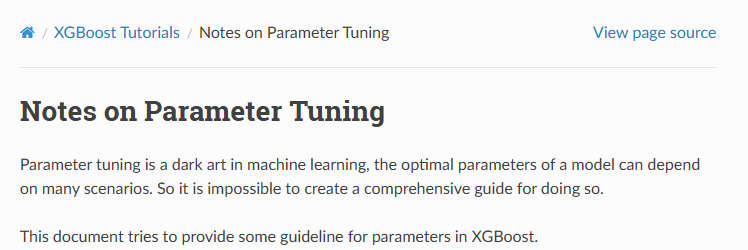

To control overfitting in XGBoost: 
- directly control model complexity (e.g. through tuning max_depth)
- add randomness to make training robust to noise (e.g. through subsample)

eta, alias learning_rate: Step size shrinkage used in update to prevent overfitting. After each boosting step, we can directly get the weights of new features, and eta shrinks the feature weights to make the boosting process more conservative.

n_estimators: The number of trees in the forest/model (?).

max_depth: Maximum depth of a tree. Increasing this value will make the model more complex and more likely to overfit. 0 indicates no limit on depth. Beware that XGBoost aggressively consumes memory when training a deep tree.

subsample: Subsample ratio of the training instances. Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees. and this will prevent overfitting. Subsampling will occur once in every boosting iteration. "Typically set subsample >= 0.5 for good results." (https://xgboost.readthedocs.io/en/release_3.2.0/parameter.html)


In [ ]:
results = classic_pipeline(model_class, param_grid, "flatten", dfs, feature_cols, results)
results = classic_pipeline(model_class, param_grid, "extract", dfs, feature_cols, results)

Feature importance plots show that the extracted features method is more explainable than the flattened features method. The feature importance std is too high to be able to conclusively determine which features are the most important for the model (flattened features). This is an argument for why we should discard this method. 

## Feature Importance for Classical ML Models

In [ ]:
from src.visualisation import plot_feature_importance_grid
plot_feature_importance_grid(results, "Flattened_features")
plot_feature_importance_grid(results, "Extracted_features")

In [ ]:
# # Plot
# import matplotlib.pyplot as plt
# def plot_feature_importance_grid(
#     results,
#     preprocessing_name,
#     max_num_features=15
# ):
#     """
#     Creates a 2x4 grid:

#     Row 1:
#         Final model feature importances

#     Row 2:
#         CV mean +/- std feature importances

#     Columns:
#         Different ML models
#     """

#     fig, axes = plt.subplots(
#         2,
#         4,
#         figsize=(22, 12)
#     )

#     fig.suptitle(
#         f"{preprocessing_name} Feature Importance",
#         fontsize=18
#     )

#     # Filter preprocessing type
#     filtered_results = [
#         r for r in results
#         if r["preprocessing"] == preprocessing_name
#     ]

#     # Sort for consistent ordering
#     filtered_results = sorted(
#         filtered_results,
#         key=lambda x: x["model"]
#     )

#     for col, result in enumerate(filtered_results):

#         model_name = result["model"]

#         # Row 1 — Final model importance
#         final_summary = get_final_importance_summary(
#             result["final_model"],
#             max_num_features=max_num_features
#         )

#         ax = axes[0, col]

#         ax.barh(
#             final_summary["Feature"],
#             final_summary["Importance"]
#         )

#         ax.invert_yaxis()

#         ax.set_xlim(0, 1.05)

#         ax.set_title(
#             f"{model_name} - Final Model"
#         )

#         ax.set_xlabel(
#             "Normalised Importance"
#         )

#         # Row 2 — CV importance
#         cv_summary = get_cv_importance_summary(
#             result["best_model_list"],
#             max_num_features=max_num_features
#         )

#         ax = axes[1, col]

#         ax.barh(
#             cv_summary.index,
#             cv_summary["Mean Importance"],
#             xerr=cv_summary["Std Importance"]
#         )

#         ax.invert_yaxis()

#         ax.set_xlim(0, 1.05)


#         ax.set_title(
#             f"{model_name} - CV Mean ± Std"
#         )

#         ax.set_xlabel(
#             "Normalised Importance"
#         )

#     plt.tight_layout()

#     plt.show()

# plot_feature_importance_grid(results, "Flattened_features")
# plot_feature_importance_grid(results, "Extracted_features")

## LSTM

In [ ]:
model_class = src.models.LSTMClassifier

In [ ]:
# For LSTM, we want to use the raw time series data instead of extracted features or flattened features.
# Load data (same data loading process as before)
from src.preprocessing import load_csvs

folder_1 = Path("..") / "pur-1-data-main" / "data" / "Task 1" / "Public Dataset" / "Gang_Lowers"
folder_2 = Path("..") / "pur-1-data-main" / "data" / "Task 1" / "Public Dataset" / "SCRAMS"

dfs = load_csvs(folder_1, folder_2)

# Clean data 
from src.preprocessing import clean_data
dfs = clean_data(dfs)

# Event IDs
event_ids = [df["ID"].iloc[0] for df in dfs]

In [ ]:
# As LSTM is sensitive to noise, we ended up only using the three most important features
feature_selected = ['Channel 4 flux', 'SS1 position', 'SS2 position']

X = np.array([df[feature_selected].values for df in dfs]) # shape (43, 800, 3)
y = np.array([df['target'].iloc[0] for df in dfs]) # shape (43,)

from src.trainDL import nested_cross_validation_DL
from src.models import LSTMClassifier

param_grid = {
    "hidden_size": [2, 4, 8],
    "lr": [1e-3, 5e-3],
}

auc_scores, acc_scores, f1_scores, all_event_ids, y_true, y_pred, train_losses, val_losses, best_model_list, best_params_list = nested_cross_validation_DL(LSTMClassifier, X, y, event_ids, param_grid)

In [ ]:
results.append({
    "model": model_class.__name__,
    "preprocessing": "Raw time series",
    "auc_scores": auc_scores,
    "acc_scores": acc_scores,
    "f1_scores": f1_scores,
    "event_ids": all_event_ids,
    "y_true": y_true,
    "y_pred": y_pred,
    "best_model_list": best_model_list,
    "best_params_list": best_params_list
})

In [ ]:
from src.visualisation import plot_5fold_training_curves

plot_5fold_training_curves(train_losses, val_losses)

In [ ]:
auc_scores =results[-1]['auc_scores']
acc_scores =results[-1]['acc_scores']
f1_scores =results[-1]['f1_scores']
y_true = results[-1]['y_true']
y_pred = results[-1]['y_pred']

from src.visualisation import print_final_metrics
print_final_metrics(auc_scores, acc_scores, f1_scores, y_true, y_pred)

In [ ]:
# Get final hyperparameters
from src.utils import get_final_param_grid
param_grid_final = get_final_param_grid(best_params_list)

# Run final cross-validation (using DL function)
from src.trainDL import retrain_with_5_fold_cv_DL
final_model, final_params = retrain_with_5_fold_cv_DL(X, y, model_class, param_grid=param_grid_final)

# Save model for later inference
from src.utils import save_model
save_model(final_model, f"{model_class.__name__}_raw_data")

In [ ]:
final_model

In [ ]:
final_params

In [ ]:
results

## Compare all models

In [ ]:
from src.visualisation import present_results_compact
present_results_compact(results)

In [ ]:
from src.visualisation import plot_all_metrics
plot_all_metrics(results)

In [ ]:
from src.visualisation import plot_confusion_matrices
plot_confusion_matrices(results)

In [ ]:
from src.utils import create_comparison_df
comparison_df = create_comparison_df(results)

from src.visualisation import plot_misclassification_matrix
plot_misclassification_matrix(comparison_df)

In [ ]:
from scipy.stats import poisson_binom

p = [3/43, 5/43, 4/43, 9/43, 3/43, 3/43, 8/43, 4/43, 7/43]

# Probability majority vote is wrong
p_mv_wrong = 1 - poisson_binom.cdf(4, p)

print(p_mv_wrong)
# 0.0016

In [ ]:
from src.utils import get_hard_events
hard_events = get_hard_events(comparison_df)

hard_events # See plots in exploration.ipynb

In [ ]:
# Look at the affected event IDs
# Plot them maybe
# Do they look outlier-like?

In [ ]:
# Statistical analysis

# Friedman test
from scipy.stats import friedmanchisquare

friedmanchisquare(
    results[0]['acc_scores'],
    results[1]['acc_scores'],
    results[2]['acc_scores'],
    results[3]['acc_scores'],
    results[4]['acc_scores'],
    results[5]['acc_scores'],
    results[6]['acc_scores'],
    results[7]['acc_scores'],
    results[8]['acc_scores'],
)

In [ ]:
# Wilcoxon signed-rank test
import numpy as np
from scipy.stats import wilcoxon
from itertools import combinations
from statsmodels.stats.multitest import multipletests

metric = 'acc_scores'  # or 'roc_auc_scores', 'f1_scores'

p_values = []
comparisons = []

for i, j in combinations(range(len(results)), 2):
    scores_i = np.array(results[i][metric])
    scores_j = np.array(results[j][metric])

    # Wilcoxon signed-rank test
    stat, p = wilcoxon(
        scores_i,
        scores_j,
        alternative='two-sided',
        method='exact'  # use exact p-values for small n
    )

    comparisons.append((i, j))
    p_values.append(p)

# Holm correction
reject, p_corrected, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method='holm'
)

# Print results
for (i, j), p_raw, p_adj, sig in zip(
        comparisons,    
        p_values,
        p_corrected,
        reject):

    print(
        f"Model {i} vs Model {j}: "
        f"raw p={p_raw:.4f}, "
        f"Holm p={p_adj:.4f}, "
        f"significant={sig}"
    )

In [ ]:
from scipy.stats import wilcoxon

rf = results[0]['acc_scores']
xgb = results[1]['acc_scores']

stat, p = wilcoxon(
    rf,
    xgb,
    alternative='two-sided',
    method='exact'
)

print(f"Statistic = {stat}")
print(f"p-value = {p}")

In [ ]:
# Plot decision tree illustrations
# find the outer fold models in the results list
dec_tree_flattened = next(r for r in results if r['model'] == 'DecisionTree' and r['preprocessing'] == 'Flattened_features')
dec_tree_extracted = next(r for r in results if r['model'] == 'DecisionTree' and r['preprocessing'] == 'Extracted_features')

In [ ]:
dec_tree_flattened

In [ ]:
# Plot decision tree illustrations
from sklearn import tree
import matplotlib.pyplot as plt

flattened = dec_tree_flattened['best_model_list'] # then later the same for extracted

from sklearn import tree
import matplotlib.pyplot as plt

for i, model in enumerate(flattened, start=1):

    plt.figure(figsize=(20,10))
    tree.plot_tree(
        model,
        feature_names=model.feature_names_in_,
        class_names=['Gang Lower', 'SCRAM'],
        filled=True,
        rounded=True,
        fontsize=16
    )

    plt.title(f"Flattened Features - Outer Fold {i}", fontsize=20)
    plt.show()

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

flattened = dec_tree_extracted['best_model_list']

for i, model in enumerate(flattened, start=1):

    plt.figure(figsize=(20, 10))

    tree.plot_tree(
        model,
        feature_names=model.feature_names_in_,
        class_names=['Gang Lower', 'SCRAM'],
        filled=True,
        rounded=True,
        fontsize=16
    )

    plt.title(f"Decision Tree - Extracted- Fold {i}", fontsize=20)

    plt.savefig(
        f"DecTree_extracted_fold{i}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

flattened = dec_tree_flattened['best_model_list']
extracted = dec_tree_extracted['best_model_list']

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(30, 40)
)

for i in range(5):

    # Flattened features
    tree.plot_tree(
        flattened[i],
        feature_names=flattened[i].feature_names_in_,
        class_names=['Gang Lower', 'SCRAM'],
        filled=True,
        rounded=True,
        fontsize=16,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Flattened - Fold {i+1}', fontsize=14)

    # Extracted features
    tree.plot_tree(
        extracted[i],
        feature_names=extracted[i].feature_names_in_,
        class_names=['Gang Lower', 'SCRAM'],
        filled=True,
        rounded=True,
        fontsize=16,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Extracted - Fold {i+1}', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

flattened = dec_tree_flattened['best_model_list']

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(25, 50)
)

for i, model in enumerate(flattened):

    tree.plot_tree(
        model,
        feature_names=model.feature_names_in_,
        class_names=['Gang Lower', 'SCRAM'],
        filled=True,
        rounded=True,
        fontsize=12,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Flattened Features - Outer Fold {i+1}",
        fontsize=18
    )

plt.tight_layout()
plt.show()

# 14.05.26: Implementing LSTM
- build LSTM class
- expand with more regularisation as necessary (see lstm_test.py)
- incorporate into current pipeline

Then:
- Update evaluation func to include F1-score (as this is what is used by the benchmark organisers)

Then: 
- Create inference.py, reload models there, and apply on blind dataset

Then: 
- Tidy up notebooks + .py-files

### First attempt: getting the pipeline working

In [ ]:
# Create new X and y for LSTM model
X = np.array([df.drop(columns=['ID','timestamp','target']).values for df in dfs]) # shape (43, 800, 10)
y = np.array([df['target'].iloc[0] for df in dfs]) # shape (43,)

# Data splitting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Create PyTorch datasets and dataloaders
from src.preprocessing import ReactorDataset # Data class
from torch.utils.data import DataLoader

train_dataset = ReactorDataset(X_train, y_train)
test_dataset = ReactorDataset(X_test, y_test)

# how to load the data. Data augmentation, making batches etc. 
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset) 

In [ ]:
from  src.models import LSTMClassifier
model = LSTMClassifier(input_size=10) # Create model instance

from src.trainDL import train_DL_model
train_losses, val_losses = train_DL_model(
    model,
    train_loader,
    test_loader
)

In [ ]:
from src.visualisation import plot_training_curves
plot_training_curves(train_losses, val_losses)
# Should add some early stopping to prevent overfitting?

In [ ]:
# AUC on test set
from src.evaluateDL import evaluate_auc
evaluate_auc(model, test_loader)
print("AUC on test set:", evaluate_auc(model, test_loader))

### Second attempt: run pipeline many times to find mean performance

In [ ]:
from src.evaluateDL import evaluate_f1
def train_lstm_pipeline(train_loader, test_loader, input_size):
    # set_seed(42) # For reproducibility # removed to see avg performance 
    model = LSTMClassifier(input_size=input_size)

    train_losses, val_losses = train_DL_model(
        model,
        train_loader,
        test_loader
    )

    auc = evaluate_auc(model, test_loader)
    f1 = evaluate_f1(model, test_loader)
    
    return train_losses, val_losses, auc, f1

In [ ]:
train_losses, val_losses = [], []
auc_array = []
for i in range(10):
    print(f"Run {i+1}/10")
    train_loss, val_loss, auc, _ = train_lstm_pipeline(train_loader, test_loader, input_size=10)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    auc_array.append(auc)

After 10 runs:

AUC scores: [0.7, 0.75, 0.9, 0.8500000000000001, 1.0, 0.7, 0.7, 0.8500000000000001, 1.0, 1.0]

The high variance comes from model training randomness (not data split randomness as it's the same split for each run)

In [ ]:
print("AUC scores:", auc_array)
print("Average AUC:", np.mean(auc_array))

In [ ]:
# To visualise 10 runs neatly:
def plot_all_training_curves(all_train_losses, all_val_losses):
    """
    Plot training and validation losses for 10 runs
    in a single figure with 10 subplots.

    Args:
        all_train_losses: list of lists
            Example:
            [
                [0.8, 0.6, 0.5, ...],   # run 1
                [0.9, 0.7, 0.55, ...],  # run 2
                ...
            ]

        all_val_losses: list of lists
            Same structure as all_train_losses
    """

    import matplotlib.pyplot as plt

    n_runs = len(all_train_losses)

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for i in range(n_runs):

        train_losses = all_train_losses[i]
        val_losses = all_val_losses[i]

        epochs = range(1, len(train_losses) + 1)

        axes[i].plot(epochs, train_losses, label="Train Loss")
        axes[i].plot(epochs, val_losses, label="Validation Loss")

        axes[i].set_title(f"Run {i+1}")
        axes[i].set_xlabel("Epoch")
        axes[i].set_ylabel("Loss")
        axes[i].legend()
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

plot_all_training_curves(train_losses, val_losses)

### Optimisation step 1: Reduce \# of features from 10 to 3

In [ ]:
# Determine which three features are most important for the LSTM model.
# From the feature importance of the flattened features: Channel 4 Flux, SS1 state, and SS2 state

feature_selected = ['Channel 4 flux', 'SS1 state', 'SS2 state']

In [ ]:
# Create new X and y for LSTM model
X = np.array([df[feature_selected].values for df in dfs]) # shape (43, 800, 3)
y = np.array([df['target'].iloc[0] for df in dfs]) # shape (43,)

# Data splitting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Create PyTorch datasets and dataloaders
from src.preprocessing import ReactorDataset # Data class
from torch.utils.data import DataLoader

train_dataset = ReactorDataset(X_train, y_train)
test_dataset = ReactorDataset(X_test, y_test)

# how to load the data. Data augmentation, making batches etc. 
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset) 

In [ ]:
train_losses, val_losses = [], []
auc_array = []
for i in range(10):
    print(f"Run {i+1}/10")
    train_loss, val_loss, auc, f1 = train_lstm_pipeline(train_loader, test_loader, input_size=len(feature_selected))
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    auc_array.append(auc)

In [ ]:
print("AUC scores:", auc_array)
print("Average AUC:", np.mean(auc_array))

In [ ]:
plot_all_training_curves(train_losses, val_losses)

Worse performance than with the full 10 features... ?
Or, at least high variance still.

### Optimisation step 2: Hyperparameter tuning

In [ ]:
# Need to be able to evaluate the model
# Using F1 score as the optimisation metric

In [ ]:
# To avoid data leakage
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42) # 0.25 x 0.8 = 0.2


# Prepare dataset 
train_dataset = ReactorDataset(X_train, y_train)
val_dataset = ReactorDataset(X_val, y_val)
test_dataset = ReactorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [ ]:
param_grid = {
    "hidden_size": [4, 8, 32],
    "num_layers": [1, 2],
    "lr": [5e-3, 1e-3, 1e-4]
}

In [ ]:
results = []

for hidden_size in param_grid["hidden_size"]:
    for lr in param_grid["lr"]:

        print(f"Training hidden_size={hidden_size}, lr={lr}")

        model = LSTMClassifier(
            input_size=len(feature_selected),
            hidden_size=hidden_size
        )

        train_losses, val_losses = train_DL_model(
            model,
            train_loader,
            val_loader,
            lr=lr
        )

        f1 = evaluate_f1(model, val_loader)
        auc = evaluate_auc(model, val_loader)

        results.append({
            "hidden_size": hidden_size,
            "lr": lr,
            "f1": f1,
            "auc": auc
        })

        print(f"F1: {f1:.4f}")
        print(f"AUC: {auc:.4f}")

In [ ]:
best = max(results, key=lambda x: x["auc"])

print("Best config:", best)

In [ ]:
results

### Trying to implement Balint's LSTM model

In [ ]:
# Seed set 
# Mean pooling implemented
# Feature selection selected

hidden_size = 4
num_layers = 1
# dropout = 0.0 # doesn't matter at num_layers=1?
epochs = 150
lr = 5e-3
# patience = 20
# weight_decay = 1e-5

# Removed scaling using StandardScaler - the data is already normalised

In [ ]:
# Cross-validation and no single-split (single split is too volatile with only 43 samples)

# Create new X and y for LSTM model
X = np.array([df[feature_selected].values for df in dfs]) # shape (43, 800, 3)
y = np.array([df['target'].iloc[0] for df in dfs]) # shape (43,)


# PIPELINE FOR CROSS-VALIDATION
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_aucs_val = []
fold_aucs_tr = []
all_train_losses = []
all_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)): 
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    samples_tr, timesteps_tr, features_tr = X_tr.shape
    samples_val, timesteps_val, features_val = X_val.shape

    train_loader = DataLoader(ReactorDataset(X_tr, y_tr), batch_size=8, shuffle=True)
    val_loader = DataLoader(ReactorDataset(X_val, y_val), batch_size=8)

    # We re-initialize the model for each fold
    set_seed(42 + fold)

    model = LSTMClassifier(
        input_size=len(feature_selected), hidden_size=4, num_layers=1
    )

    train_losses, val_losses = train_DL_model(
        model,
        train_loader,
        val_loader,
        epochs=150,
        lr=5e-3,
    )

    train_auc = evaluate_auc(model, train_loader)
    val_auc = evaluate_auc(model, val_loader)

    fold_aucs_tr.append(train_auc if not np.isnan(train_auc) else 0)
    fold_aucs_val.append(val_auc if not np.isnan(val_auc) else 0)
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

    print(
        f"Fold {fold + 1}/5 | TR AUC: {train_auc:.4f} || VAL AUC: {val_auc:.4f} | Epochs: {len(train_losses)}"
    )

print("\n" + "=" * 50)
print("FINAL CROSS-VALIDATION METRICS")
print(f"Train AUC: {np.mean(fold_aucs_tr):.4f} ± {np.std(fold_aucs_tr):.4f}")
print(f"Val   AUC: {np.mean(fold_aucs_val):.4f} ± {np.std(fold_aucs_val):.4f}")
print("=" * 50)

# Visualization: 2x3 Grid to plot all 5 loss curves + Final Bar Chart
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(5):
    axes[i].plot(all_train_losses[i], label="Train Loss", color="blue")
    axes[i].plot(all_val_losses[i], label="Val Loss", color="orange")
    axes[i].set_title(f"Loss Curve - Fold {i + 1}")
    axes[i].set_xlabel("Epochs")
    axes[i].set_ylabel("Loss")
    axes[i].legend()

# Plot 6: Average Metrics
metrics = ["Tr AUC", "Val AUC"]
vals = [
    np.mean(fold_aucs_tr),
    np.mean(fold_aucs_val),
]
errors = [
    np.std(fold_aucs_tr),
    np.std(fold_aucs_val),
]

x = np.arange(len(metrics))
axes[5].bar(
    x,
    vals,
    yerr=errors,
    capsize=8,
    color=["lightblue", "orange"],
)
axes[5].set_xticks(x)
axes[5].set_xticklabels(metrics)
axes[5].set_title("Average CV Performance")
axes[5].set_ylabel("Score")
axes[5].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig("lstm_test_results.png")
print("\nResults plot saved as 'lstm_test_results.png'")
plt.show()



Getting strong performance! Now, to follow the rigorous methodology I used in the traditional ML model training, I should really use nested cross-validation. Let's attempt that now. 

### Nested cross-validation for hyperparameter tuning of LSTM model

In [ ]:
# The following code was generated by ChatGPT to modify the above code to be nested cross-validation.
# https://chatgpt.com/share/6a0b357e-5180-8325-806a-8295cd7ab08a

In [ ]:
# ==========================================
# NESTED CROSS-VALIDATION PIPELINE FOR LSTM
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader

# ==========================================
# CREATE DATA
# ==========================================

# Shape: (43, 800, 3)
X = np.array([df[feature_selected].values for df in dfs])

# Shape: (43,)
y = np.array([df["target"].iloc[0] for df in dfs])

# ==========================================
# HYPERPARAMETER GRID
# ==========================================

param_grid = {
    "hidden_size": [2, 4, 8],
    "lr": [1e-3, 5e-3],
}

# ==========================================
# OUTER CV (FINAL EVALUATION)
# ==========================================

outer_kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

outer_fold_aucs = []

all_train_losses = []
all_val_losses = []

for outer_fold, (train_outer_idx, test_outer_idx) in enumerate(
    outer_kf.split(X, y)
):

    print("\n" + "=" * 70)
    print(f"OUTER FOLD {outer_fold + 1}/5")
    print("=" * 70)

    # --------------------------------------
    # OUTER SPLIT
    # --------------------------------------

    X_train_outer = X[train_outer_idx]
    y_train_outer = y[train_outer_idx]

    X_test_outer = X[test_outer_idx]
    y_test_outer = y[test_outer_idx]

    # ======================================
    # INNER CV (HYPERPARAMETER TUNING)
    # ======================================

    inner_kf = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    best_auc = -np.inf
    best_params = None

    for hidden_size in param_grid["hidden_size"]:
        for lr in param_grid["lr"]:

            inner_fold_aucs = []

            for inner_fold, (train_inner_idx, val_inner_idx) in enumerate(
                inner_kf.split(X_train_outer, y_train_outer)
            ):

                # ------------------------------
                # INNER SPLIT
                # ------------------------------

                X_train_inner = X_train_outer[train_inner_idx]
                y_train_inner = y_train_outer[train_inner_idx]

                X_val_inner = X_train_outer[val_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                # ------------------------------
                # DATALOADERS
                # ------------------------------

                train_loader = DataLoader(
                    ReactorDataset(X_train_inner, y_train_inner),
                    batch_size=8,
                    shuffle=True
                )

                val_loader = DataLoader(
                    ReactorDataset(X_val_inner, y_val_inner),
                    batch_size=8
                )

                # ------------------------------
                # REINITIALIZE MODEL
                # ------------------------------

                set_seed(42 + outer_fold + inner_fold)

                model = LSTMClassifier(
                    input_size=len(feature_selected),
                    hidden_size=hidden_size,
                    num_layers=1
                )

                # ------------------------------
                # TRAIN
                # ------------------------------

                train_losses, val_losses = train_DL_model(
                    model,
                    train_loader,
                    val_loader,
                    epochs=150,
                    lr=lr,
                )

                # ------------------------------
                # EVALUATE
                # ------------------------------

                val_auc = evaluate_auc(model, val_loader)

                if np.isnan(val_auc):
                    val_auc = 0

                inner_fold_aucs.append(val_auc)

            # ----------------------------------
            # MEAN INNER CV PERFORMANCE
            # ----------------------------------

            mean_inner_auc = np.mean(inner_fold_aucs)

            print(
                f"hidden={hidden_size}, lr={lr:.0e} "
                f"| INNER AUC = {mean_inner_auc:.4f}"
            )

            # ----------------------------------
            # TRACK BEST HYPERPARAMETERS
            # ----------------------------------

            if mean_inner_auc > best_auc:
                best_auc = mean_inner_auc

                best_params = {
                    "hidden_size": hidden_size,
                    "lr": lr
                }

    # ======================================
    # RETRAIN USING BEST HYPERPARAMETERS
    # ======================================

    print("\nBest Hyperparameters:")
    print(best_params)

    train_outer_loader = DataLoader(
        ReactorDataset(X_train_outer, y_train_outer),
        batch_size=8,
        shuffle=True
    )

    test_outer_loader = DataLoader(
        ReactorDataset(X_test_outer, y_test_outer),
        batch_size=8
    )

    # --------------------------------------
    # REINITIALIZE FINAL MODEL
    # --------------------------------------

    set_seed(100 + outer_fold)

    final_model = LSTMClassifier(
        input_size=len(feature_selected),
        hidden_size=best_params["hidden_size"],
        num_layers=1
    )

    # --------------------------------------
    # TRAIN FINAL MODEL
    # --------------------------------------

    train_losses, val_losses = train_DL_model(
        final_model,
        train_outer_loader,
        test_outer_loader,
        epochs=150,
        lr=best_params["lr"],
    )

    # --------------------------------------
    # FINAL OUTER TEST EVALUATION
    # --------------------------------------

    train_auc = evaluate_auc(final_model, train_outer_loader)
    test_auc = evaluate_auc(final_model, test_outer_loader)

    if np.isnan(test_auc):
        test_auc = 0

    outer_fold_aucs.append(test_auc)

    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

    print(
        f"\nFINAL OUTER RESULTS "
        f"| TR AUC: {train_auc:.4f} "
        f"| TEST AUC: {test_auc:.4f}"
    )

# ==========================================
# FINAL RESULTS
# ==========================================

print("\n" + "=" * 70)
print("FINAL NESTED CROSS-VALIDATION RESULTS")
print("=" * 70)

print(
    f"Outer Test AUC: "
    f"{np.mean(outer_fold_aucs):.4f} ± {np.std(outer_fold_aucs):.4f}"
)

# ==========================================
# PLOTTING
# ==========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(5):

    axes[i].plot(
        all_train_losses[i],
        label="Train Loss"
    )

    axes[i].plot(
        all_val_losses[i],
        label="Validation Loss"
    )

    axes[i].set_title(f"Outer Fold {i + 1}")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()

# ------------------------------------------
# BAR CHART
# ------------------------------------------

metrics = ["Outer Test AUC"]

vals = [np.mean(outer_fold_aucs)]

errors = [np.std(outer_fold_aucs)]

x = np.arange(len(metrics))

axes[5].bar(
    x,
    vals,
    yerr=errors,
    capsize=8
)

axes[5].set_xticks(x)
axes[5].set_xticklabels(metrics)
axes[5].set_ylim(0, 1.1)
axes[5].set_title("Nested CV Performance")

plt.tight_layout()

plt.savefig("nested_cv_results.png")

print("\nResults plot saved as 'nested_cv_results.png'")

plt.show()

In [ ]:
# ==========================================
# FINAL MODEL TRAINING (NO MORE TUNING)
# ==========================================

import numpy as np
from torch.utils.data import DataLoader

# ------------------------------------------
# FULL DATASET
# ------------------------------------------

X = np.array([df[feature_selected].values for df in dfs])
y = np.array([df["target"].iloc[0] for df in dfs])

# ------------------------------------------
# SELECT FINAL HYPERPARAMETERS
# (from nested CV results)
# ------------------------------------------

final_params = {
    "hidden_size": 2,
    "lr": 5e-3,
    "num_layers": 1
}

# ------------------------------------------
# DATASET + LOADER
# ------------------------------------------

full_dataset = ReactorDataset(X, y)

full_loader = DataLoader(
    full_dataset,
    batch_size=8,
    shuffle=True
)

# ------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------

set_seed(42)

# ------------------------------------------
# FINAL MODEL
# ------------------------------------------

final_model = LSTMClassifier(
    input_size=len(feature_selected),
    hidden_size=final_params["hidden_size"],
    num_layers=final_params["num_layers"]
)

# ------------------------------------------
# TRAIN ON FULL DATA
# ------------------------------------------

train_losses, _ = train_DL_model(
    final_model,
    full_loader,
    full_loader,  # same data used (no validation split anymore)
    epochs=150,
    lr=final_params["lr"],
)

# ------------------------------------------
# SAVE MODEL (optional)
# ------------------------------------------

import torch

torch.save(final_model.state_dict(), "final_lstm_model.pt")

print("Final model trained on full dataset and saved.")

In [ ]:
# Hannah tester nye funksjoner:
feature_selected = ['Channel 4 flux', 'SS1 state', 'SS2 state']

X = np.array([df[feature_selected].values for df in dfs]) # shape (43, 800, 3)
y = np.array([df['target'].iloc[0] for df in dfs]) # shape (43,)

from src.trainDL import nested_cross_validation_DL
from src.models import LSTMClassifier

param_grid = {
    "hidden_size": [2, 4, 8],
    "lr": [1e-3, 5e-3],
}

auc_scores, acc_scores, f1_scores, y_true, y_pred, train_losses, val_losses = nested_cross_validation_DL(LSTMClassifier, X, y, param_grid)

#### Thoughts week 13

So, after testing the two most promising models on the test set, the final result is that XGBoost outperforms Random Forest Classifier. (Though, interestingly, Random Forest performs better on the train set - overfitting probably.)

No hyperparameter tuning has been conducted. Test AUC of 1, test accuracy of 0.889. (Is this good enough?) 

Haven't included LSTM yet - this has been a bit of a hurdle. Want to get back to this! Was a lot of new theory and code and error messages. 


# Week 14: LSTM implementation

##### Notes
We use the final timestep representation to classify the whole sequence.

Alternative: mean pooling over time (sometimes better for noisy signals).

Could try both? And compare?

If we want mean pooling, use t in (200-500). Interesting. 

Also, for last timestep: Should maybe not use last, but t=400 or something like this. 

#### Training 
Forward pass: model makes predictions. 

Loss calculation: compare predicted vs. actual values.

Backpropagation: update weights.

Detach hidden states: prevent gradient buildup.

In my first attempt at implementing LSTM here, I get varying results. Test AUC scores between 0.35-0.8.

Now: 
- Add plot over epochs, train & test eval + learning rate? (done) 
- Add early stopping (regularisation)
- Add scheduler (for learning rate) (right now it's constant)

- Hyperparameter tuning: change hidden_size and num_layers, (learning_rate too?)

- Try to overfit / learn the training set and then move back / add regularisation. (Decrease performance on train, increase on test)

## Week 16

- LSTM - where are we here? I think it should still be mentioned in the thesis as an attempted model with promising theory even if it didn't work in practice.

- Hyperparameter tuning. Nested cross validation (Has support in literature for scarce data). Also want to try leave-one-out, though this has less support (Maximum data usage for training, good for scarce data. Cons: very high variance.). 

GridSearchCV evaluates hyperparameters using CV (inner CV specified by StratifiedKFold), then re-trains one final model on full training data. 

Q: Is there a point in nesting the LOOCV?



My metric values vary greatly between runs. This is a result of my low number of events. Even a mis-classification of 1 or 2 extra events has a large impact on the evaluation metrics.     

### Thoughts Week 9

Feature extraction could be done better. 
- Look at blind dataset, can I drop the features that are constants? 
- Can I drop other features that are shown to be less important? Keep for now.
- Should explain the feature extraction better, should I add other extracted features - perhaps late stage SS1/SS2 position? If I found from flattened features that this could be interesting to look at. 

Evaluation
- Included metrics AUC and accuracy, but have seen from cross-validation that the way the data is split greatly affects model performance. 
- Evaluate metrics on train vs. test to have a look at overfitting. Obviously (?) the models perform better on the train data than the test data. But is the extent problematic? 

Cross-validation
- Happy with the cross-validation as-is for feature extracted data. 
- How to do this differently if I want to keep temporal nature? (E.g. for deep learning)

Hyperparameter tuning
- Nonexistent right now because of high-performing models making it difficult to justify. 
- Could try out optuna if needed later on

LSTM
- batch size: how many events train the model simultaneously. Then the weights and biases are nudged by the next batch, and the next batch and so on.
- Should the custom train and evaluate funcs work? 
- Get mediocre results. Too many weights/biases, too few samples. 
- Could try windowing to increase number of samples, then have to be careful about data leakage. Keep all windows from the same event in the same fold. 
